# KinMS Resolution Test: Cusp vs. Core (Sub-beam Discrimination)

Builds Cusp (NFW-like) and Core (Burkert-like) cubes with KinMS, simulates ALMA-like visibilities from the Cusp, then uses uvfit's **TemplateCubeModel** to fit both templates. Δχ² shows the wrong model (Core) is rejected at high SNR even though the feature (0.2″) is 5× smaller than the beam (1″).

Requires: `pip install uvfit kinms`

## 1. Imports and helpers

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import RegularGridInterpolator
from scipy.ndimage import gaussian_filter

from kinms import KinMS
from uvfit import UVDataset, TemplateCubeModel, Fitter, NUFFTEngine


def rotation_curve_cusp_core(radius_arcsec, r_core_arcsec, v_flat_kms, inner_slope):
    """V(r) = v_flat * min(1, (r/r_core)^inner_slope). inner_slope=0.5 → cusp, 1.0 → core."""
    r = np.maximum(radius_arcsec, 1e-10)
    x = r / r_core_arcsec
    return v_flat_kms * np.minimum(1.0, x ** inner_slope)


def build_kinms_cube(
    npix, n_chan, cell_size_arcsec, channel_width_kms,
    inc, pa, h_r, r_core_arcsec, v_flat_kms, inner_slope,
    beam_arcsec=0.1,
):
    """Build a single KinMS cube (Cusp or Core) with given rotation curve slope."""
    fov_arcsec = npix * cell_size_arcsec
    vel_range = n_chan * channel_width_kms
    radius = np.linspace(0.01, fov_arcsec * 0.6, max(100, int(20 * r_core_arcsec / cell_size_arcsec)))
    sbprof = np.exp(-radius / h_r)
    vel = rotation_curve_cusp_core(radius, r_core_arcsec, v_flat_kms, inner_slope)

    kin = KinMS(
        fov_arcsec, fov_arcsec, vel_range,
        cell_size_arcsec, channel_width_kms,
        beamSize=[beam_arcsec, beam_arcsec, 0],
        verbose=False,
    )
    cube_kinms = kin.model_cube(
        inc=inc, sbProf=sbprof, sbRad=radius, velProf=vel, posAng=pa,
    )
    # KinMS returns (x, y, v); uvfit expects (n_chan, ny, nx)
    cube = np.transpose(cube_kinms, (2, 1, 0)).astype(np.float64)
    cube = cube / (np.sum(cube) + 1e-30)
    return cube


def simulate_visibilities(cube, cell_size_arcsec, u, v, snr=30, seed=42):
    """Sample cube at (u,v) in wavelengths; add Gaussian noise for target SNR."""
    rng = np.random.default_rng(seed)
    n_chan, ny, nx = cube.shape
    cell_rad = cell_size_arcsec * np.pi / (180.0 * 3600.0)
    u_grid = np.fft.fftshift(np.fft.fftfreq(nx, d=cell_rad))
    v_grid = np.fft.fftshift(np.fft.fftfreq(ny, d=cell_rad))
    n_bl = u.shape[0]
    vis = np.zeros((n_bl, n_chan), dtype=np.complex128)
    for ch in range(n_chan):
        ft = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(cube[ch])))
        interp_re = RegularGridInterpolator(
            (v_grid, u_grid), ft.real, method="linear", bounds_error=False, fill_value=0.0
        )
        interp_im = RegularGridInterpolator(
            (v_grid, u_grid), ft.imag, method="linear", bounds_error=False, fill_value=0.0
        )
        points = np.stack([v, u], axis=-1)
        vis[:, ch] = interp_re(points) + 1j * interp_im(points)
    if snr > 0:
        vis_rms = np.sqrt(np.mean(np.abs(vis) ** 2))
        noise_sigma = vis_rms / snr
        vis = vis + noise_sigma * (rng.standard_normal(vis.shape) + 1j * rng.standard_normal(vis.shape))
        weights = np.full_like(vis.real, 1.0 / noise_sigma ** 2)
    else:
        weights = np.ones_like(vis.real)
    return vis, weights

## 2. Build Cusp and Core cubes

In [28]:
cell_size_arcsec = 0.05
npix = 80
n_chan = 32
channel_width_kms = 15.0
r_core_arcsec = 0.2
inc, pa, h_r = 60.0, 0.0, 0.5
v_flat_kms = 180.0
beam_arcsec = 0.1

print("Building Cusp cube (NFW-like, V ∝ r^0.5)...")
cube_cusp = build_kinms_cube(
    npix, n_chan, cell_size_arcsec, channel_width_kms,
    inc, pa, h_r, r_core_arcsec, v_flat_kms, inner_slope=0.5,
    beam_arcsec=beam_arcsec,
)
print("Building Core cube (Burkert-like, V ∝ r)...")
cube_core = build_kinms_cube(
    npix, n_chan, cell_size_arcsec, channel_width_kms,
    inc, pa, h_r, r_core_arcsec, v_flat_kms, inner_slope=1.0,
    beam_arcsec=beam_arcsec,
)
print(f"Cusp shape: {cube_cusp.shape}, Core shape: {cube_core.shape}")

Building Cusp cube (NFW-like, V ∝ r^0.5)...
Building Core cube (Burkert-like, V ∝ r)...
Cusp shape: (32, 80, 80), Core shape: (32, 80, 80)


### Rotation curves V(r): the radial profiles that differ

Both cubes use the **same surface brightness** profile (exponential in radius), so their moment-0 maps and moment-0 radial profiles are identical. The only difference is the **rotation curve** V(r): Cusp has V ∝ r^0.5 (steeper rise), Core has V ∝ r (linear rise). That difference shows up in the channel/velocity structure and in the visibilities, not in moment-0.

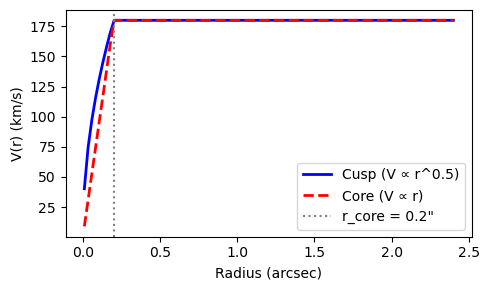

In [29]:
# Plot the input rotation curves (same radius grid as in build_kinms_cube)
fov_arcsec = npix * cell_size_arcsec
radius = np.linspace(0.01, fov_arcsec * 0.6, max(100, int(20 * r_core_arcsec / cell_size_arcsec)))
v_cusp = rotation_curve_cusp_core(radius, r_core_arcsec, v_flat_kms, 0.5)
v_core = rotation_curve_cusp_core(radius, r_core_arcsec, v_flat_kms, 1.0)

fig_v, ax_v = plt.subplots(figsize=(5, 3))
ax_v.plot(radius, v_cusp, "b-", lw=2, label="Cusp (V ∝ r^0.5)")
ax_v.plot(radius, v_core, "r--", lw=2, label="Core (V ∝ r)")
ax_v.axvline(r_core_arcsec, color="gray", ls=":", label=f"r_core = {r_core_arcsec}\"")
ax_v.set_xlabel("Radius (arcsec)")
ax_v.set_ylabel("V(r) (km/s)")
ax_v.legend()
# ax_v.set_title("Rotation curves")
plt.tight_layout()
plt.show()

## 3. UV coverage and templates

In [30]:
cell_rad = cell_size_arcsec * np.pi / (180.0 * 3600.0)
u_max_wav = 0.4 / (npix * cell_rad)
n_baselines = 250
rng = np.random.default_rng(123)
u = rng.uniform(-u_max_wav, u_max_wav, size=n_baselines)
v = rng.uniform(-u_max_wav, u_max_wav, size=n_baselines)

freq_center = 230.538e9
chan_width_hz = 1e6
freqs = freq_center + (np.arange(n_chan) - n_chan // 2) * chan_width_hz

model_cusp = TemplateCubeModel(template_cube=cube_cusp, cell_size_arcsec=cell_size_arcsec)
model_core = TemplateCubeModel(template_cube=cube_core, cell_size_arcsec=cell_size_arcsec)
initial = {"dx": 0.0, "dy": 0.0, "dv": 0.0, "flux_scale": 1.0}

## 4. Step 3: Sub-beam discrimination (Δχ² vs SNR)

In [ ]:
snr_list = [3, 10, 30, 100]
results_snr = []
for snr_target in snr_list:
    vis_data, weights = simulate_visibilities(
        cube_cusp, cell_size_arcsec, u, v, snr=snr_target
    )
    uvdata = UVDataset.from_mock(u=u, v=v, vis=vis_data, weights=weights, freqs=freqs)
    result_cusp = Fitter(uvdata=uvdata, forward_model=model_cusp).fit(
        initial_params=initial, method="L-BFGS-B"
    )
    result_core = Fitter(uvdata=uvdata, forward_model=model_core).fit(
        initial_params=initial, method="L-BFGS-B"
    )
    delta_chi2 = result_core.chi2 - result_cusp.chi2
    results_snr.append((snr_target, result_cusp.chi2, result_core.chi2, delta_chi2))

print(f"{'SNR':>6}  {'χ²(Cusp)':>12}  {'χ²(Core)':>12}  {'Δχ²':>10}  (Δχ² > 0 => reject Core)")
for snr_target, chi2_cusp, chi2_core, delta_chi2 in results_snr:
    print(f"{snr_target:>6}  {chi2_cusp:>12.1f}  {chi2_core:>12.1f}  {delta_chi2:>10.1f}")
print("At high SNR, Δχ² is large and positive => uvfit correctly rejects the Core model.")

   SNR      χ²(Cusp)      χ²(Core)         Δχ²  (Δχ² > 0 => reject Core)
     3       16104.3       16152.6        48.4
    10       16104.3       16499.1       394.8
    30       16104.3       19291.5      3187.2
   100       16104.3       50093.3     33989.0
At high SNR, Δχ² is large and positive => uvfit correctly rejects the Core model.


## 5. Refit at SNR=100 for Step 4 (clean vs residuals)

In [ ]:
snr_target = snr_list[-1]
vis_data, weights = simulate_visibilities(
    cube_cusp, cell_size_arcsec, u, v, snr=snr_target
)
uvdata = UVDataset.from_mock(u=u, v=v, vis=vis_data, weights=weights, freqs=freqs)
result_cusp = Fitter(uvdata=uvdata, forward_model=model_cusp).fit(
    initial_params=initial, method="L-BFGS-B"
)
result_core = Fitter(uvdata=uvdata, forward_model=model_core).fit(
    initial_params=initial, method="L-BFGS-B"
)

## 6. Step 4: Clean image (blurred) vs uv-fit residuals

In [54]:
mom0_cusp = np.sum(cube_cusp, axis=0)
mom0_core = np.sum(cube_core, axis=0)
beam_arcsec_clean = 1.0
beam_pix = beam_arcsec_clean / cell_size_arcsec
sigma_beam = beam_pix / (2 * np.sqrt(2 * np.log(2)))
mom0_clean_blurred = gaussian_filter(mom0_cusp, sigma=sigma_beam)

engine = NUFFTEngine(cell_size=cell_size_arcsec)
cube_cusp_fit = model_cusp.generate_cube(result_cusp.params)
model_vis_cusp = engine.degrid(
    cube_cusp_fit, uvdata.u, uvdata.v, uvdata.freqs,
    phase_shift_arcsec=(result_cusp.params["dx"], result_cusp.params["dy"]),
)
residual_vis_cusp = np.abs(uvdata.vis_data - model_vis_cusp)
cube_core_fit = model_core.generate_cube(result_core.params)
model_vis_core = engine.degrid(
    cube_core_fit, uvdata.u, uvdata.v, uvdata.freqs,
    phase_shift_arcsec=(result_core.params["dx"], result_core.params["dy"]),
)
residual_vis_core = np.abs(uvdata.vis_data - model_vis_core)

### Figure 1: Cusp vs Core moment-0 and moment-1

**Moment-0** (top row) is the **same by design**: both cubes use the same surface brightness; only the **rotation curve** V(r) differs (see plot above). **Moment-1** (bottom row) is the mean velocity field; it differs between Cusp and Core because of their different V(r). The difference shows up in channel/velocity structure, in the visibilities, and in moment-1.

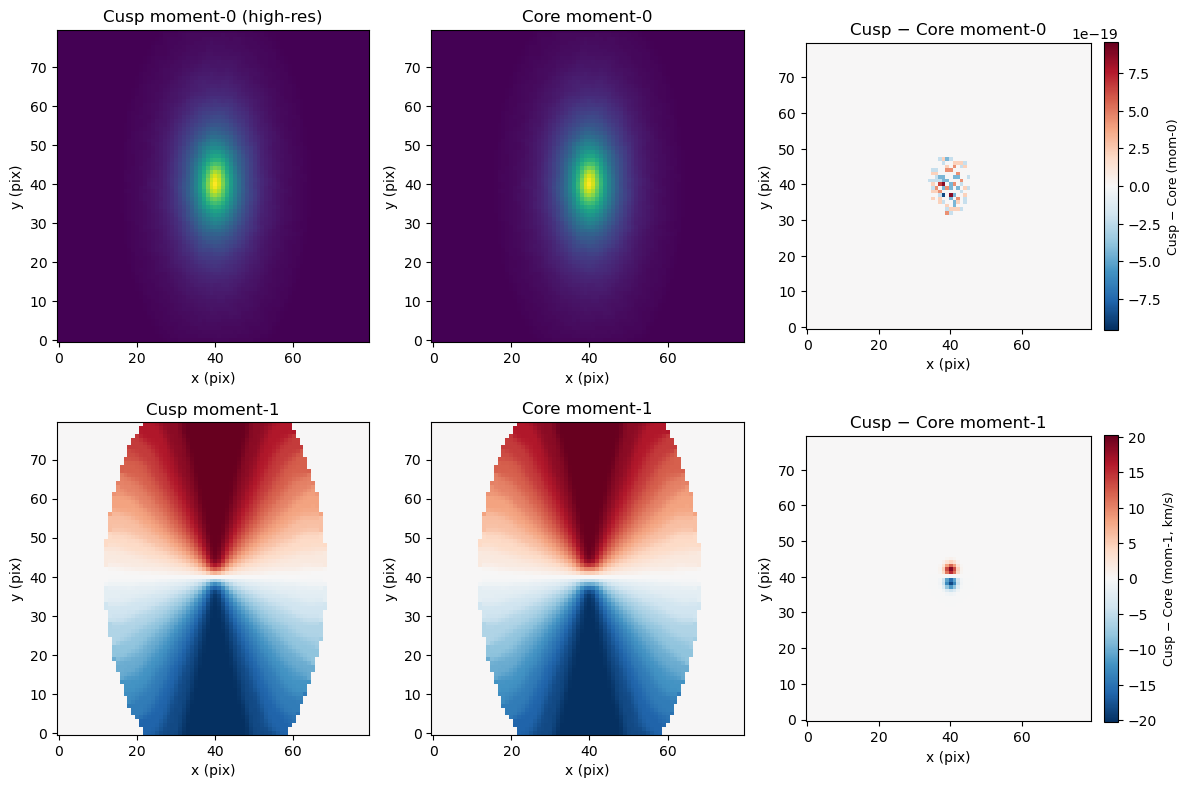

In [ ]:
# Figure 1: Moment-0 and moment-1 (velocity field), Cusp vs Core.
# Moment-0 is the same by design; moment-1 shows the rotation-curve difference.

# Velocity axis for moment-1 (channel centers in km/s)
vel_axis = (np.arange(n_chan) - n_chan // 2) * channel_width_kms
mom1_cusp = np.sum(vel_axis[:, None, None] * cube_cusp, axis=0) / (mom0_cusp + 1e-30)
mom1_core = np.sum(vel_axis[:, None, None] * cube_core, axis=0) / (mom0_core + 1e-30)

fig1, axes1 = plt.subplots(2, 3, figsize=(12, 8))

# Row 0: Moment-0
im_cusp = axes1[0, 0].imshow(
    mom0_cusp,
    origin="lower", aspect="equal", cmap="viridis",
    vmin=0, vmax=max(np.nanmax(mom0_cusp), np.nanmax(mom0_core))
)
axes1[0, 0].set_title("Cusp moment-0 (high-res)")

im_core = axes1[0, 1].imshow(
    mom0_core,
    origin="lower", aspect="equal", cmap="viridis",
    vmin=0, vmax=max(np.nanmax(mom0_cusp), np.nanmax(mom0_core))
)
axes1[0, 1].set_title("Core moment-0")

mom0_diff = mom0_cusp - mom0_core
diff_max0 = np.nanmax(np.abs(mom0_diff))
im_diff0 = axes1[0, 2].imshow(
    mom0_diff,
    origin="lower", aspect="equal", cmap="RdBu_r",
    vmin=-diff_max0 * 1.1, vmax=diff_max0 * 1.1
)
axes1[0, 2].set_title("Cusp − Core moment-0")

# Row 1: Moment-1 (velocity field)
v_shared = max(np.nanmax(np.abs(mom1_cusp)), np.nanmax(np.abs(mom1_core)))
im_mom1_cusp = axes1[1, 0].imshow(
    mom1_cusp,
    origin="lower", aspect="equal", cmap="RdBu_r",
    vmin=-v_shared, vmax=v_shared
)
axes1[1, 0].set_title("Cusp moment-1")

im_mom1_core = axes1[1, 1].imshow(
    mom1_core,
    origin="lower", aspect="equal", cmap="RdBu_r",
    vmin=-v_shared, vmax=v_shared
)
axes1[1, 1].set_title("Core moment-1")

mom1_diff = mom1_cusp - mom1_core
diff_max1 = np.nanmax(np.abs(mom1_diff))
im_diff1 = axes1[1, 2].imshow(
    mom1_diff,
    origin="lower", aspect="equal", cmap="RdBu_r",
    vmin=-diff_max1 * 1.1, vmax=diff_max1 * 1.1
)
axes1[1, 2].set_title("Cusp − Core moment-1")

for row in range(2):
    for col in range(3):
        axes1[row, col].set_xlabel("x (pix)")
        axes1[row, col].set_ylabel("y (pix)")

cbar0 = fig1.colorbar(im_diff0, ax=axes1[0, 2], fraction=0.046, pad=0.04)
cbar0.set_label("Cusp − Core (mom-0)", fontsize=9)
cbar1 = fig1.colorbar(im_diff1, ax=axes1[1, 2], fraction=0.046, pad=0.04)
cbar1.set_label("Cusp − Core (mom-1, km/s)", fontsize=9)

plt.tight_layout()
plt.savefig("kinms_resolution_test_out.png", dpi=100)
plt.show()

### Figure 2: Clean image vs uv-fit residuals

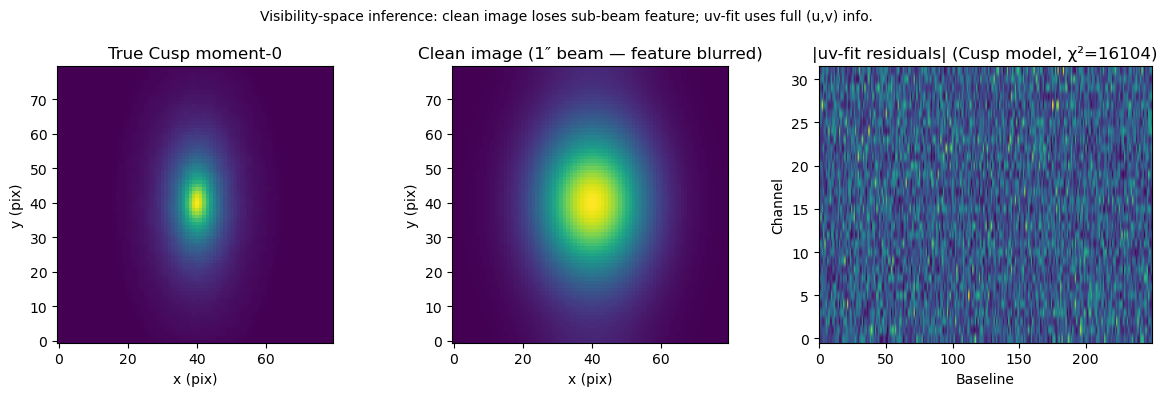

In [56]:
fig2, axes2 = plt.subplots(1, 3, figsize=(12, 4))
axes2[0].imshow(mom0_cusp, origin="lower", aspect="equal")
axes2[0].set_title("True Cusp moment-0")
axes2[1].imshow(mom0_clean_blurred, origin="lower", aspect="equal")
axes2[1].set_title("Clean image (1″ beam — feature blurred)")
axes2[2].imshow(residual_vis_cusp.T, origin="lower", aspect="auto")
axes2[2].set_title(f"|uv-fit residuals| (Cusp model, χ²={result_cusp.chi2:.0f})")
axes2[2].set_xlabel("Baseline")
axes2[2].set_ylabel("Channel")
for ax in axes2[:2]:
    ax.set_xlabel("x (pix)")
    ax.set_ylabel("y (pix)")
plt.suptitle("Visibility-space inference: clean image loses sub-beam feature; uv-fit uses full (u,v) info.", fontsize=10)
plt.tight_layout()
plt.savefig("kinms_resolution_test_clean_vs_residuals.png", dpi=100)
plt.show()

### Figure 3: Cusp vs Core fit residuals (Core fits worse)

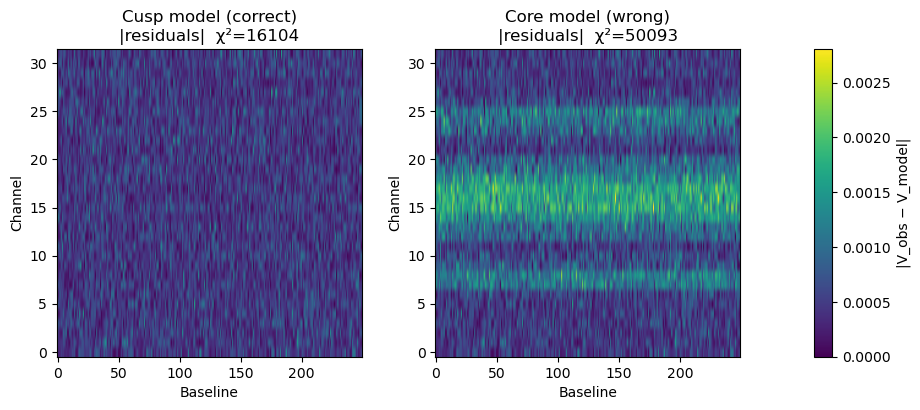

In [57]:
vmax = max(residual_vis_cusp.max(), residual_vis_core.max())
fig3 = plt.figure(figsize=(10, 4))
gs = fig3.add_gridspec(1, 3, width_ratios=[1, 1, 0.06], wspace=0.35)
ax0 = fig3.add_subplot(gs[0])
ax1 = fig3.add_subplot(gs[1])
cax = fig3.add_subplot(gs[2])
im0 = ax0.imshow(residual_vis_cusp.T, origin="lower", aspect="auto", vmin=0, vmax=vmax)
ax0.set_title(f"Cusp model (correct)\n|residuals|  χ²={result_cusp.chi2:.0f}")
ax0.set_xlabel("Baseline")
ax0.set_ylabel("Channel")
im1 = ax1.imshow(residual_vis_core.T, origin="lower", aspect="auto", vmin=0, vmax=vmax)
ax1.set_title(f"Core model (wrong)\n|residuals|  χ²={result_core.chi2:.0f}")
ax1.set_xlabel("Baseline")
ax1.set_ylabel("Channel")
fig3.colorbar(im1, cax=cax, label="|V_obs − V_model|")
plt.savefig("kinms_resolution_test_cusp_vs_core_residuals.png", dpi=100)
plt.show()